# Olist E-Commerce Analysis


## Notebook 02: EDA and Business Analysis


**Objective:** Explore the cleaned dataset to answer key business questions about
sales performance, delivery efficiency, payment behavior, and customer satisfaction.

### What We Will Perform in This Notebook
1. **Import libraries and load clean data** — bring in the cleaned CSVs from Notebook 01
2. **Sales analysis** — revenue by category, top-selling categories, monthly trends
3. **Delivery analysis** — average delivery time, on-time vs late deliveries
4. **Payment analysis** — payment type distribution, installment behavior
5. **Customer satisfaction analysis** — review score distribution, score vs delivery time
6. **Geographic analysis** — revenue/orders by state

### Step 1: Import libraries and load clean data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

master_df = pd.read_csv("master_df_clean.csv")

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_columns:
    master_df[col] = pd.to_datetime(master_df[col])

print(master_df.shape)
master_df.head()

(119143, 40)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,No Title,No Comment,2018-08-18,2018-08-22 19:07:58


### Step 2: Sales analysis

In [5]:
# Total revenue and total orders overview
total_revenue = master_df['price'].sum()
total_orders = master_df['order_id'].nunique()

print(f"Total Revenue: R$ {total_revenue:,.2f}")
print(f"Total Orders: {total_orders}")

Total Revenue: R$ 14,273,699.65
Total Orders: 99441


product_category_name_english
health_beauty            1301947.97
watches_gifts            1254322.95
bed_bath_table           1107249.09
sports_leisure           1029603.88
computers_accessories     950053.69
furniture_decor           772096.17
housewares                668880.94
cool_stuff                664637.13
auto                      618395.50
garden_tools              519473.33
Name: price, dtype: float64


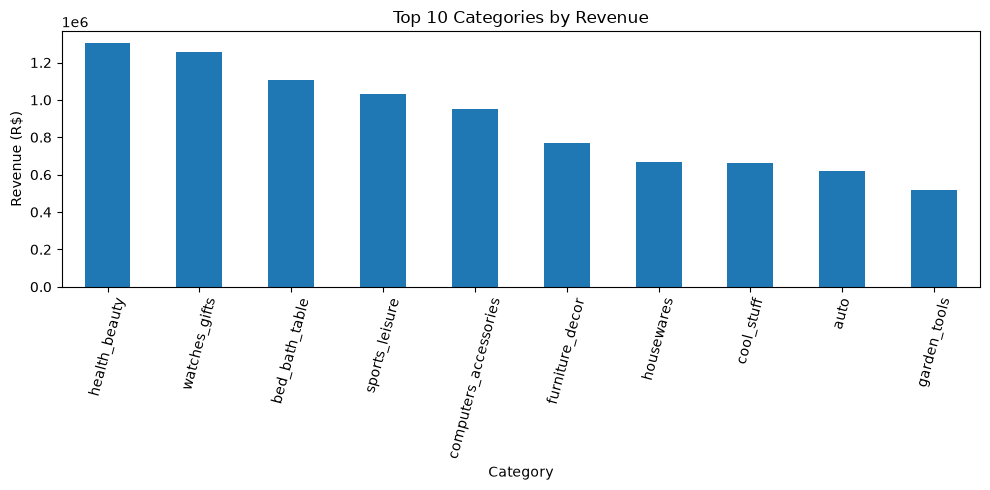

In [6]:
# Revenue by product category (top 10)
category_revenue = master_df.groupby('product_category_name_english')['price'].sum()
category_revenue = category_revenue.sort_values(ascending=False).head(10)

print(category_revenue)

plt.figure(figsize=(10, 5))
category_revenue.plot(kind='bar')
plt.title('Top 10 Categories by Revenue')
plt.xlabel('Category')
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

order_month
2016-09        267.36
2016-10      51068.92
2016-12         10.90
2017-01     129895.32
2017-02     262013.86
2017-03     398117.44
2017-04     392595.36
2017-05     549226.84
2017-06     456867.47
2017-07     536906.96
2017-08     606026.98
2017-09     665047.38
2017-10     697457.32
2017-11    1055072.10
2017-12     773574.02
2018-01     993701.49
2018-02     889512.29
2018-03    1029589.67
2018-04    1031717.62
2018-05    1032699.42
2018-06     910053.03
2018-07     927401.38
2018-08     884731.52
2018-09        145.00
2018-10          0.00
Freq: M, Name: price, dtype: float64


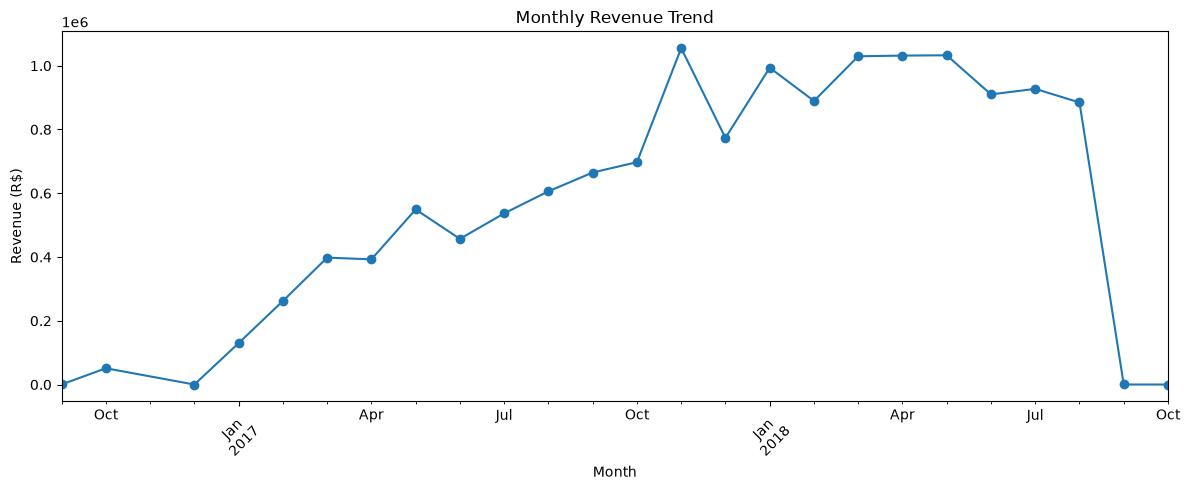

In [8]:
# Monthly revenue trend
master_df['order_month'] = master_df['order_purchase_timestamp'].dt.to_period('M')
monthly_revenue = master_df.groupby('order_month')['price'].sum()

print(monthly_revenue)

plt.figure(figsize=(12, 5))
monthly_revenue.plot(kind='line', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Step 3: Delivery Analysis 

In [9]:
# Calculate delivery time (in days) from purchase to actual delivery
master_df['delivery_time_days'] = (
    master_df['order_delivered_customer_date'] - master_df['order_purchase_timestamp']
).dt.days

print(master_df['delivery_time_days'].describe())

count    115722.000000
mean         12.022589
std           9.454922
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_time_days, dtype: float64


In [10]:
# Compare actual delivery date vs estimated delivery date
master_df['delivery_delay_days'] = (
    master_df['order_delivered_customer_date'] - master_df['order_estimated_delivery_date']
).dt.days

# Positive value = delivered late, negative/zero = on time or early
late_deliveries = (master_df['delivery_delay_days'] > 0).sum()
on_time_deliveries = (master_df['delivery_delay_days'] <= 0).sum()

print(f"Late deliveries: {late_deliveries}")
print(f"On-time or early deliveries: {on_time_deliveries}")

Late deliveries: 7559
On-time or early deliveries: 108163


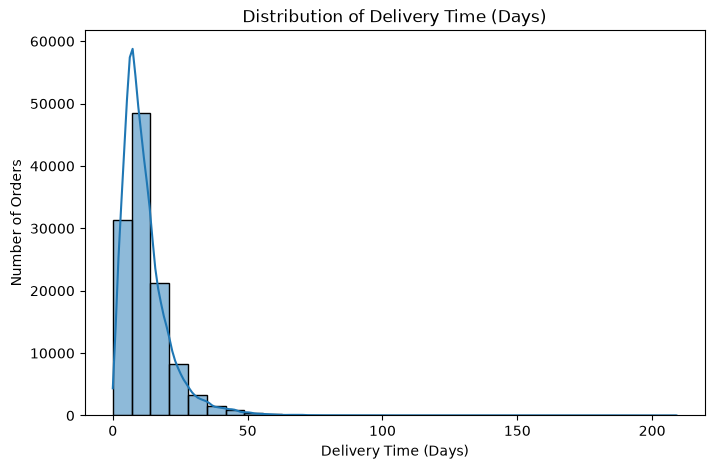

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(master_df['delivery_time_days'].dropna(), bins=30, kde=True)
plt.title('Distribution of Delivery Time (Days)')
plt.xlabel('Delivery Time (Days)')
plt.ylabel('Number of Orders')
plt.show()

delivery_status
Very Late (6+ days)         1.738180
Unknown                     1.750685
Slightly Late (1-5 days)    2.939854
On Time / Early             4.205585
Name: review_score, dtype: float64


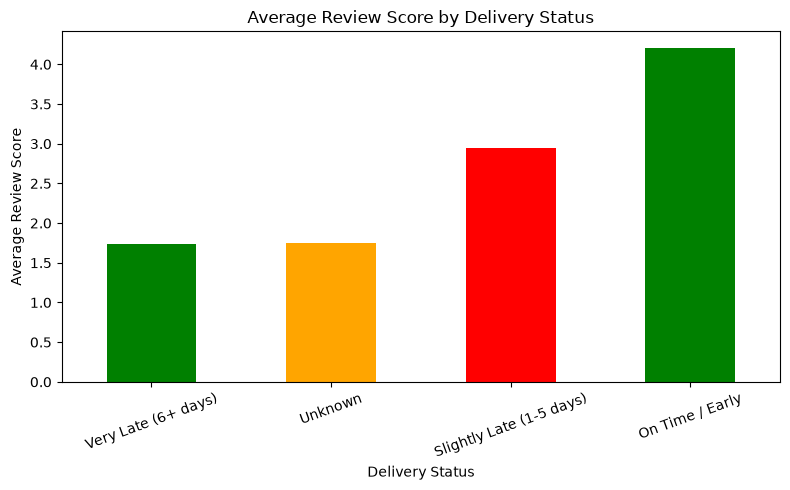

In [13]:
#Delivery Analysis — Does Delivery Delay Affect Review Score?

# Group delivery outcome into simple categories
def delivery_status(days):
    if pd.isna(days):
        return 'Unknown'
    elif days <= 0:
        return 'On Time / Early'
    elif days <= 5:
        return 'Slightly Late (1-5 days)'
    else:
        return 'Very Late (6+ days)'

master_df['delivery_status'] = master_df['delivery_delay_days'].apply(delivery_status)

# Average review score by delivery status
avg_score_by_status = master_df.groupby('delivery_status')['review_score'].mean().sort_values()

print(avg_score_by_status)

plt.figure(figsize=(8, 5))
avg_score_by_status.plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Average Review Score by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Note on "Unknown":** Some orders don't have a `delivery_delay_days` value because
`order_delivered_customer_date` is missing — meaning the order was never delivered,
still in transit, or cancelled. These are labeled "Unknown" instead of being
forced into a delivery status they don't actually have.

### Step 4: Payment Analysis

Since master_df is merged at the order-item level, payment info repeats for
orders with multiple items. We remove those duplicates first so each payment
is counted only once per order.

In [16]:
# Get one payment record per order (avoid double-counting from multiple items per order)
payments_unique = master_df.drop_duplicates(subset=['order_id', 'payment_sequential'])

print(payments_unique.shape)

(103887, 44)


payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


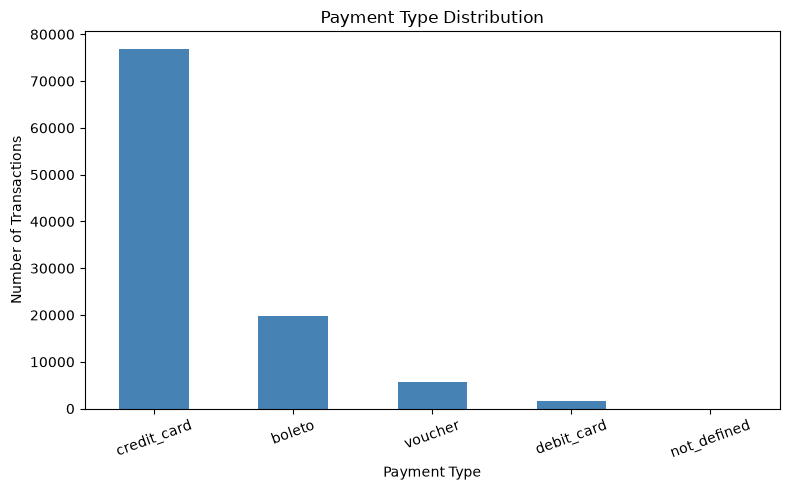

In [17]:
# Payment type distribution
payment_type_counts = payments_unique['payment_type'].value_counts()

print(payment_type_counts)

plt.figure(figsize=(8, 5))
payment_type_counts.plot(kind='bar', color='steelblue')
plt.title('Payment Type Distribution')
plt.xlabel('Payment Type')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

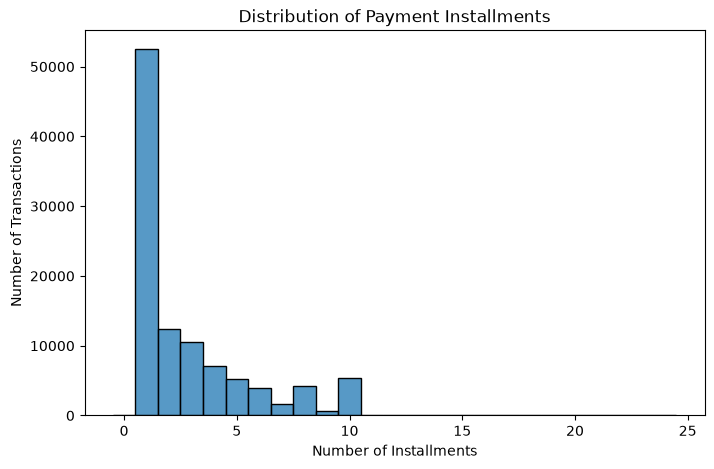

count    103886.000000
mean          2.853349
std           2.687051
min           0.000000
25%           1.000000
50%           1.000000
75%           4.000000
max          24.000000
Name: payment_installments, dtype: float64


In [18]:
# Installment behavior
plt.figure(figsize=(8, 5))
sns.histplot(payments_unique['payment_installments'], bins=24, discrete=True)
plt.title('Distribution of Payment Installments')
plt.xlabel('Number of Installments')
plt.ylabel('Number of Transactions')
plt.show()

print(payments_unique['payment_installments'].describe())

payment_type
credit_card    163.319021
boleto         145.034435
debit_card     142.570170
voucher         65.703354
not_defined      0.000000
Name: payment_value, dtype: float64


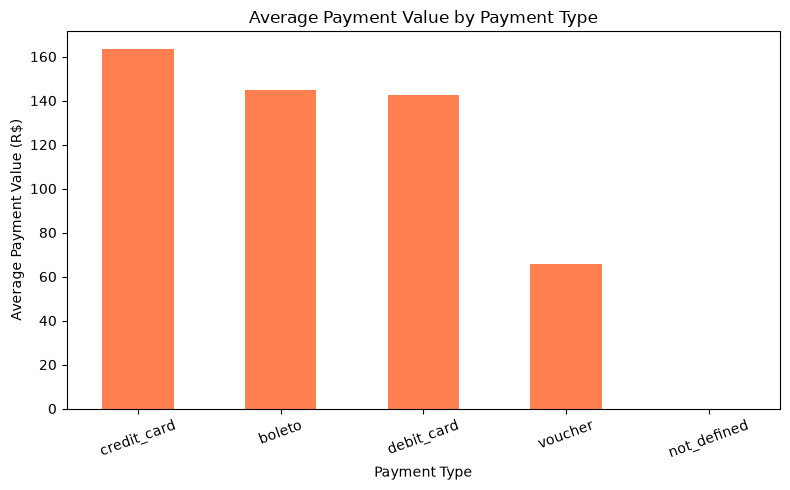

In [19]:
# Average payment value by payment type
avg_value_by_type = payments_unique.groupby('payment_type')['payment_value'].mean().sort_values(ascending=False)

print(avg_value_by_type)

plt.figure(figsize=(8, 5))
avg_value_by_type.plot(kind='bar', color='coral')
plt.title('Average Payment Value by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Average Payment Value (R$)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Step 5: Customer Satisfaction Analysis

review_score
1.0    11353
2.0     3133
3.0     8124
4.0    19044
5.0    57019
Name: count, dtype: int64


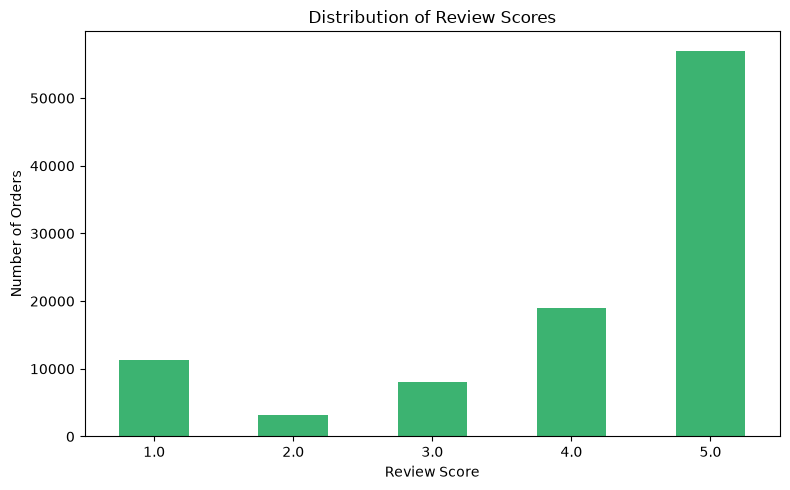

In [20]:
# Overall review score distribution
review_counts = master_df.drop_duplicates(subset=['order_id'])['review_score'].value_counts().sort_index()

print(review_counts)

plt.figure(figsize=(8, 5))
review_counts.plot(kind='bar', color='mediumseagreen')
plt.title('Distribution of Review Scores')
plt.xlabel('Review Score')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

                               avg_review_score  order_count
product_category_name_english                               
office_furniture                       3.526791         1273
fashion_male_clothing                  3.548611          112
fixed_telephony                        3.672862          217
audio                                  3.840849          350
construction_tools_safety              3.848485          167
bed_bath_table                         3.890605         9417
home_confort                           3.907563          397
furniture_decor                        3.912158         6449
furniture_living_room                  3.913793          422
art                                    3.935484          202


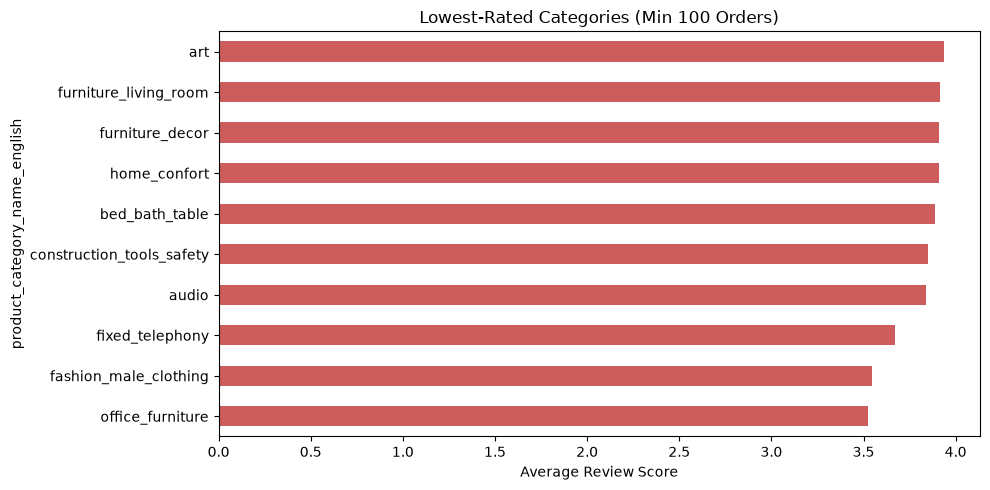

In [21]:
# Average review score by top 10 product categories
avg_score_by_category = master_df.groupby('product_category_name_english')['review_score'].mean()
order_count_by_category = master_df.groupby('product_category_name_english')['order_id'].nunique()

# Only look at categories with a decent number of orders (avoid misleading small samples)
category_summary = pd.DataFrame({
    'avg_review_score': avg_score_by_category,
    'order_count': order_count_by_category
})
category_summary = category_summary[category_summary['order_count'] >= 100]
category_summary = category_summary.sort_values('avg_review_score')

print(category_summary.head(10))

plt.figure(figsize=(10, 5))
category_summary['avg_review_score'].head(10).plot(kind='barh', color='indianred')
plt.title('Lowest-Rated Categories (Min 100 Orders)')
plt.xlabel('Average Review Score')
plt.tight_layout()
plt.show()

                               avg_review_score  order_count
product_category_name_english                               
books_general_interest                 4.438503          512
books_technical                        4.375465          260
food_drink                             4.324138          227
luggage_accessories                    4.295945         1034
food                                   4.228963          450
fashion_shoes                          4.223443          240
home_appliances_2                      4.212687          234
pet_shop                               4.197030         1710
stationery                             4.188339         2311
computers                              4.184332          181


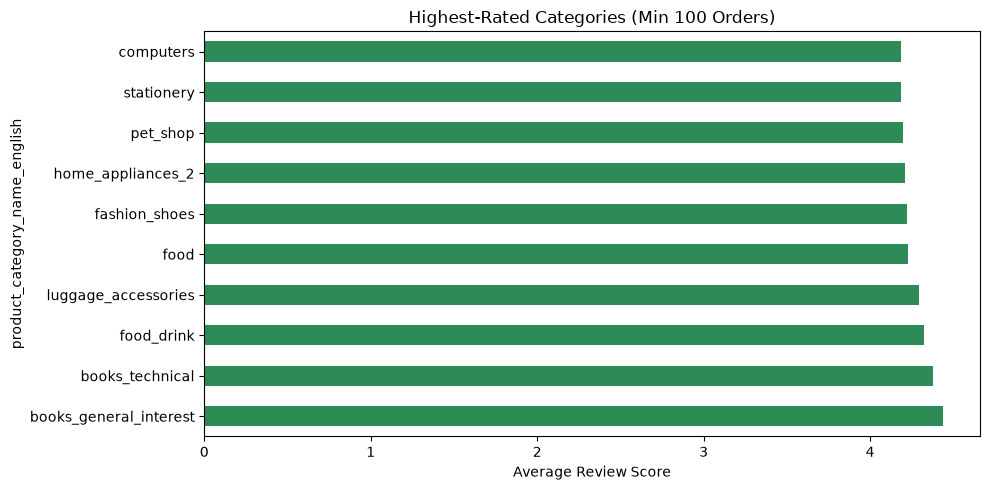

In [22]:
# Highest-rated categories (min 100 orders)
category_summary_sorted_high = category_summary.sort_values('avg_review_score', ascending=False)

print(category_summary_sorted_high.head(10))

plt.figure(figsize=(10, 5))
category_summary_sorted_high['avg_review_score'].head(10).plot(kind='barh', color='seagreen')
plt.title('Highest-Rated Categories (Min 100 Orders)')
plt.xlabel('Average Review Score')
plt.tight_layout()
plt.show()

### Step 6: Geolocation Analysis

                total_revenue  total_orders
customer_state                             
SP                 5477008.74         41746
RJ                 1921752.53         12852
MG                 1645847.27         11635
RS                  791716.84          5466
PR                  708794.22          5045
BA                  543243.99          3380
SC                  539896.20          3637
DF                  315122.29          2140
GO                  313198.27          2020
ES                  284771.30          2033


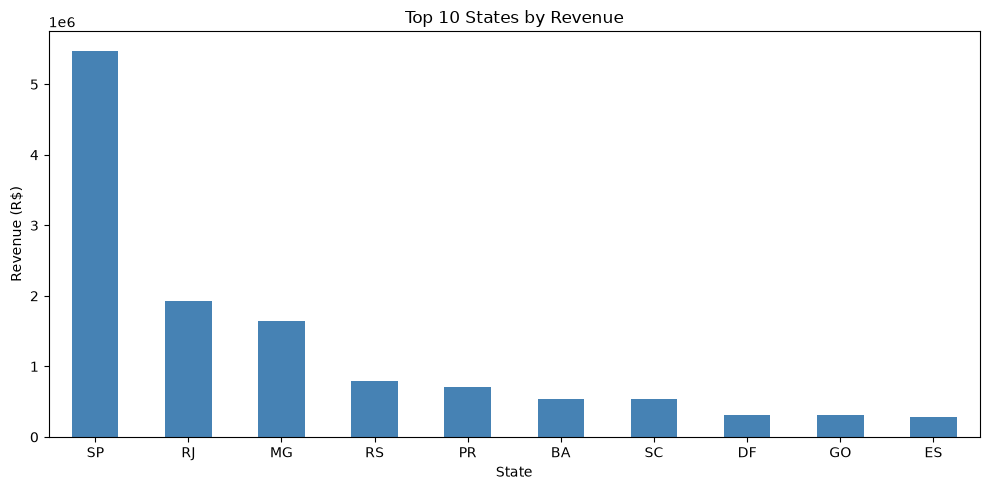

In [23]:
# Revenue and order count by customer state
state_summary = master_df.groupby('customer_state').agg(
    total_revenue=('price', 'sum'),
    total_orders=('order_id', 'nunique')
).sort_values('total_revenue', ascending=False)

print(state_summary.head(10))

plt.figure(figsize=(10, 5))
state_summary['total_revenue'].head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 States by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

customer_state
BA    18.734684
ES    15.235116
GO    14.903967
RJ    14.774957
RS    14.703888
SC    14.513443
DF    12.501430
PR    11.523074
MG    11.499963
SP     8.274160
Name: delivery_time_days, dtype: float64


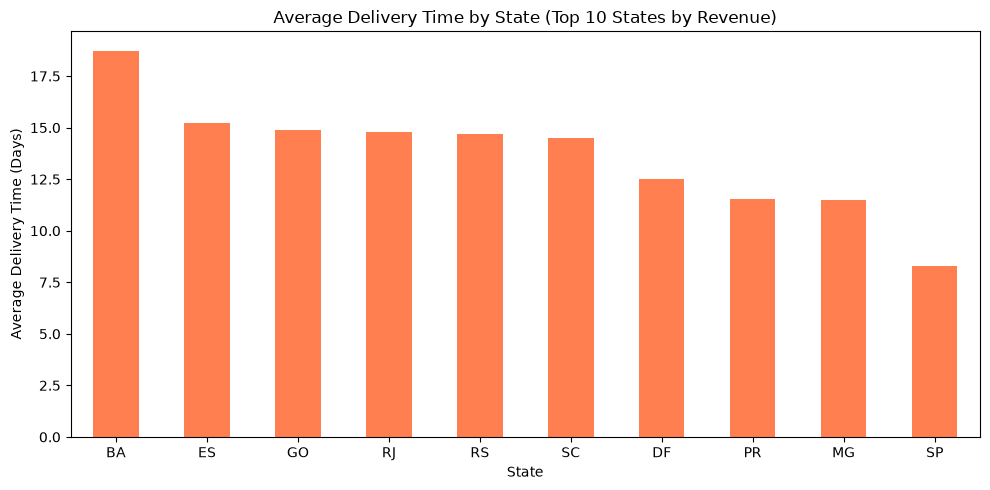

In [24]:
# Average delivery time by state (top 10 by order volume, for relevance)
top_states = state_summary.head(10).index
delivery_by_state = master_df[master_df['customer_state'].isin(top_states)].groupby('customer_state')['delivery_time_days'].mean().sort_values(ascending=False)

print(delivery_by_state)

plt.figure(figsize=(10, 5))
delivery_by_state.plot(kind='bar', color='coral')
plt.title('Average Delivery Time by State (Top 10 States by Revenue)')
plt.xlabel('State')
plt.ylabel('Average Delivery Time (Days)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()